# Telecom Customer Churn Prediction
#Prepared by : Abhishek B Panchal

# Table of Contents

1. Problem Statement
2. Week 1: Data preparation & insight Generation
4. Week 2: Model Development
5. Week 3: Optimization & Boosting
6. Week 4: Interpreability & Final reporting
7. Business Recommendations
8. Project Conclusion

## Problem Statement

ConnectTel is facing customer churn, which results in revenue loss. The objective of this project is to build a Machine Learning model that predicts whether a customer is likely to churn based on demographic, service, and account information.

The project includes:
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Machine Learning Models
- Model Evaluation
- Explainable AI using SHAP

In [81]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warning Messages
import warnings
warnings.filterwarnings('ignore')

# Display Graphs Inside Notebook
%matplotlib inline

# Set Graph Style
sns.set_style("whitegrid")



In [82]:
df = pd.read_csv("../dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [83]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [84]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [85]:
df.shape

(7043, 21)

In [86]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [88]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [89]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [90]:
df.duplicated().sum()

np.int64(0)

In [91]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

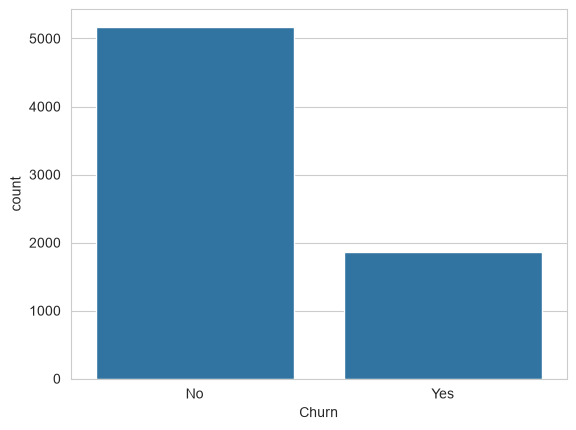

In [92]:
sns.countplot(x="Churn", data=df)
plt.show()

### Observation

- Most customers did not churn.
- Around 26.5% of customers have churned.
- The dataset is imbalanced because the number of non-churn customers is much higher than churn customers.

# Exploratory Data Analysis (EDA)

In this section, we explore the relationships between customer attributes and churn to identify patterns that may help build a predictive model.

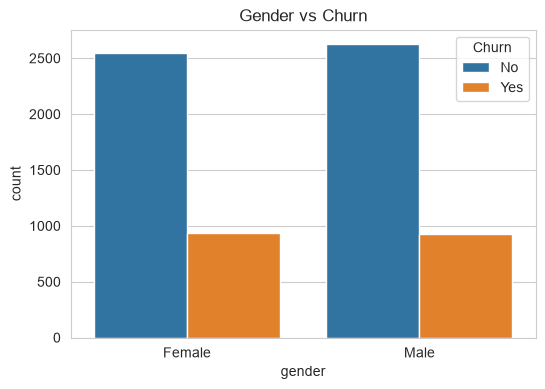

In [93]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Gender vs Churn")
plt.savefig("../images/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

- Male and Female customers have almost identical churn behavior.
- Gender alone is not a strong predictor of churn.

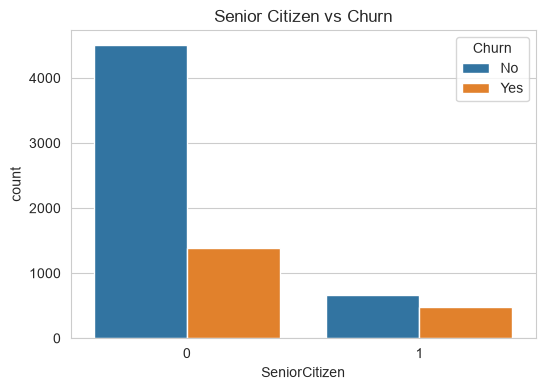

In [94]:
plt.figure(figsize=(6,4))
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)
plt.title("Senior Citizen vs Churn")
plt.savefig("../images/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

- Senior citizens appear to churn more frequently than younger customers.

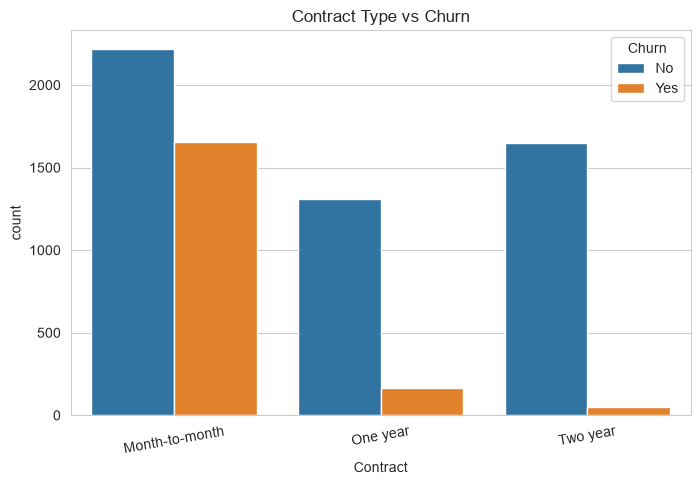

In [95]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=10)
plt.savefig("../images/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

- Customers with Month-to-Month contracts have the highest churn rate.
- One-year and Two-year contract customers are much more loyal.

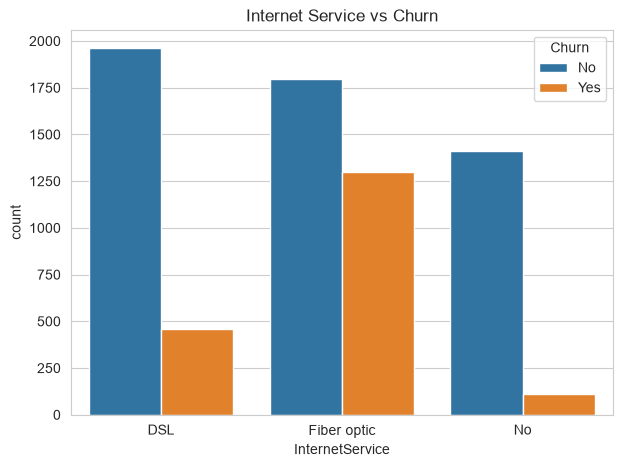

In [96]:
plt.figure(figsize=(7,5))
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Internet Service vs Churn")
plt.savefig("../images/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

- Fiber Optic customers show higher churn compared to DSL customers.
- Customers without internet service have the lowest churn.

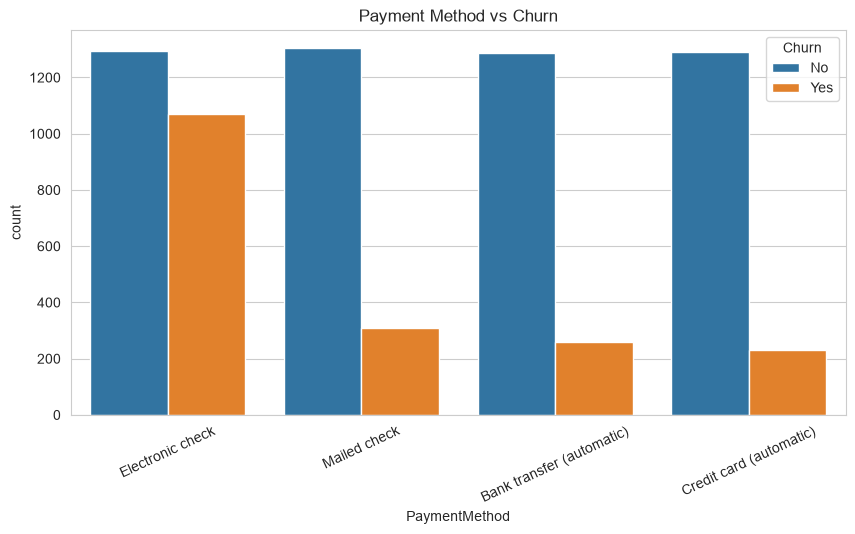

In [97]:
plt.figure(figsize=(10,5))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=25)
plt.savefig("../images/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

- Electronic Check users show the highest churn rate.

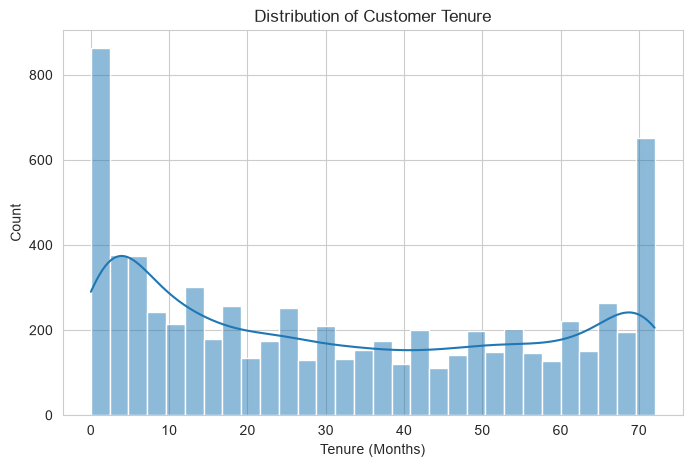

In [98]:
plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.savefig("../images/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

- Many customers have recently joined the company.
- There is also a group of long-term customers with high tenure.

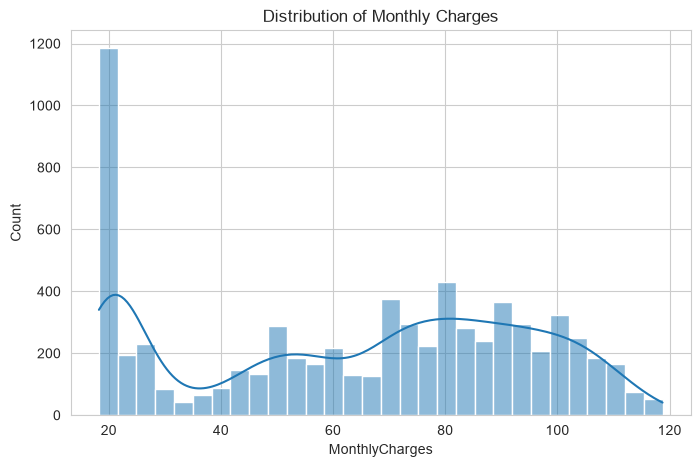

In [99]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Distribution of Monthly Charges")
plt.savefig("../images/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

- Monthly charges are spread across a wide range.
- Most customers pay between moderate and high monthly charges.

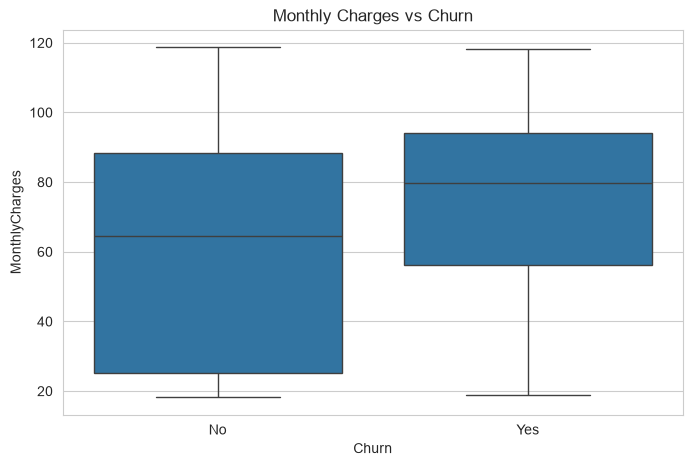

In [100]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.savefig("../images/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

- Customers who churn usually have lower tenure.
- Long-term customers are less likely to leave.

# Data Cleaning

In this section, we clean the dataset by handling incorrect data types, missing values, and preparing the data for feature engineering.

In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [102]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [103]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [104]:
df.dropna(inplace=True)

In [105]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [106]:
df.duplicated().sum()

np.int64(0)

In [107]:
df.drop_duplicates(inplace=True)

In [108]:
df.shape

(7032, 21)

# Feature Engineering

New features are created from existing data to improve the predictive power of the machine learning model.

In [109]:
tenure_safe = df["tenure"].replace(0, 1)

In [110]:
df["TotalChargesPerTenure"] = df["TotalCharges"] / tenure_safe

In [111]:
df[["TotalCharges", "tenure", "TotalChargesPerTenure"]].head()

,TotalCharges,tenure,TotalChargesPerTenure
0,29.85,1,29.850000
1,1889.50,34,55.573529
2,108.15,2,54.075000
3,1840.75,45,40.905556
4,151.65,2,75.825000


In [112]:
services = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["ServiceCount"] = (df[services] == "Yes").sum(axis=1)

In [113]:
df[["ServiceCount"]].head()

,ServiceCount
0,1
1,3
2,3
3,3
4,1


In [114]:
df["LongTermCustomer"] = (df["tenure"] >= 24).astype(int)

In [115]:
df[["tenure", "LongTermCustomer"]].head(10)

,tenure,LongTermCustomer
0,1,0
1,34,1
2,2,0
3,45,1
4,2,0
5,8,0
6,22,0
7,10,0
8,28,1
9,62,1


# EDA Summary (Business Insights)

Based on the Exploratory Data Analysis (EDA), the following key business insights were identified:

1. Customers with **Month-to-Month contracts** have the highest churn rate. This indicates that customers without long-term commitments are more likely to leave the company.

2. Customers using **Fiber Optic Internet Service** churn more frequently than DSL users. This suggests that service quality, pricing, or customer expectations may be contributing to customer dissatisfaction.

3. Customers paying **higher monthly charges** are more likely to churn than customers with lower monthly charges.

4. Customers with **short tenure** are at a higher risk of churn, while customers who have stayed with the company for a longer period are more loyal.

5. Customers using **Electronic Check** as their payment method show a higher churn rate compared to other payment methods.

6. **Senior Citizens** have a relatively higher churn rate than younger customers.

7. Gender does not appear to have a significant impact on customer churn, as both male and female customers exhibit similar churn behavior.

8. Customers subscribed to **One-Year** and **Two-Year contracts** are much less likely to churn than customers with Month-to-Month contracts.

## Business Recommendation

Based on these findings, ConnectTel should focus its customer retention strategy on:
- Offering discounts or incentives to Month-to-Month customers to encourage long-term contracts.
- Investigating customer satisfaction among Fiber Optic users.
- Providing loyalty rewards to new customers during their first year.
- Offering personalized retention campaigns for customers with high monthly charges.
- Encouraging customers to switch from Electronic Check to more stable payment methods.

In [116]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalChargesPerTenure,ServiceCount,LongTermCustomer
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.850000,1,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,55.573529,3,1
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,54.075000,3,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.905556,3,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,75.825000,1,0


In [117]:
df.to_csv("../processed_data/Telco_Cleaned.csv", index=False)

In [118]:

import os
os.listdir("../processed_data")

['Telco_Cleaned.csv']

# Week 2: Model Development

## Goal

The objective of this phase is to prepare the cleaned dataset for Machine Learning and build classification models that can predict customer churn.

### Tasks

- Load the cleaned dataset.
- Prepare features (X) and target variable (y).
- Encode categorical variables into numerical values.
- Split the dataset into training and testing sets.
- Scale numerical features where required.
- Train a Logistic Regression model.
- Train a Random Forest Classifier.
- Evaluate model performance.
- Implement Cross-Validation to measure model generalization.

## Step 1: Load the Cleaned Dataset

The cleaned dataset created during Week 1 will be used for model development. This ensures that all missing values, incorrect data types, and engineered features are already prepared for machine learning.

In [119]:
df = pd.read_csv("../processed_data/Telco_Cleaned.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalChargesPerTenure,ServiceCount,LongTermCustomer
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.850000,1,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,55.573529,3,1
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,54.075000,3,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.905556,3,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,75.825000,1,0


## Step 2: Remove Unnecessary Columns

The `customerID` column is a unique identifier for each customer and does not contribute to predicting customer churn. Therefore, it is removed from the dataset before training the models.

In [120]:
df.drop("customerID", axis=1, inplace=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalChargesPerTenure,ServiceCount,LongTermCustomer
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.850000,1,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,No,55.573529,3,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,54.075000,3,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.905556,3,1
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,75.825000,1,0


## Step 3: Define Features and Target Variable

Machine Learning models require:

- **Features (X):** The independent variables used for prediction.
- **Target (y):** The dependent variable that the model learns to predict.

In this project:

- Features include customer demographics, services, contract details, and engineered features.
- The target variable is **Churn**, which indicates whether a customer leaves the company.

In [121]:
X = df.drop("Churn", axis=1)
y = df["Churn"]
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (7032, 22)
Target Shape : (7032,)


## Step 4: Encode Categorical Variables

Machine Learning algorithms cannot process text values directly. Therefore, all categorical features such as gender, contract type, internet service, and payment method are converted into numerical format using One-Hot Encoding.

The `drop_first=True` parameter is used to avoid multicollinearity by removing one redundant category from each encoded feature.

In [122]:
categorical_columns = X.select_dtypes(include="object").columns

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,TotalChargesPerTenure,ServiceCount,LongTermCustomer,gender_Male,Partner_Yes,Dependents_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,29.850000,1,0,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,55.573529,3,1,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,54.075000,3,0,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,40.905556,3,1,True,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,75.825000,1,0,False,False,False,...,False,False,False,False,False,False,True,False,True,False


## Step 5: Encode the Target Variable

The target variable contains two categories:

- No
- Yes

These values are converted into numerical values where:

- No = 0
- Yes = 1

This format is required for machine learning algorithms.

In [123]:
y = y.map({"No":0,"Yes":1})

y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

## Step 6: Split the Dataset into Training and Testing Sets

The dataset is divided into training and testing sets. The model learns patterns from the training data and its performance is evaluated using the testing data. An 80:20 split is used, where 80% of the data is used for training and 20% for testing.

In [124]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (5625, 33)
Testing Features  : (1407, 33)
Training Target   : (5625,)
Testing Target    : (1407,)


## Step 7: Feature Scaling

Feature scaling standardizes numerical values so that features with larger ranges do not dominate the machine learning model. Logistic Regression performs better when numerical features are scaled.

In [125]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Step 8: Logistic Regression

Logistic Regression is used as the baseline classification model. It predicts whether a customer will churn based on the probability of belonging to the churn class.


In [126]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

## Step 9: Logistic Regression Predictions

The trained Logistic Regression model is used to predict customer churn on the testing dataset.

In [127]:
y_pred_lr = lr_model.predict(X_test_scaled)

## Step 10: Logistic Regression Evaluation

The model is evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix to measure its predictive performance.

In [128]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy : 0.8059701492537313

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.58      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407


Confusion Matrix

[[917 116]
 [157 217]]


## Step 11: Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [129]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## Step 12: Random Forest Predictions

The trained Random Forest model predicts customer churn on the testing dataset.

In [130]:
y_pred_rf = rf_model.predict(X_test)

## Step 13: Random Forest Evaluation

The performance of the Random Forest model is measured using standard classification evaluation metrics.

In [131]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy : 0.7974413646055437

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407


Confusion Matrix

[[930 103]
 [182 192]]


## Step 14: Cross Validation

Cross Validation evaluates the model on multiple subsets of the data to estimate how well it will perform on unseen data.

In [132]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores :", cv_scores)
print("Average Accuracy :", cv_scores.mean())

Cross Validation Scores : [0.79317697 0.80099502 0.77169275 0.80369844 0.79018492]
Average Accuracy : 0.7919496199150559


# Week 2 Summary

During this phase, the cleaned dataset was prepared for machine learning by encoding categorical variables and splitting the data into training and testing sets. Logistic Regression and Random Forest models were trained and evaluated using multiple performance metrics. Cross Validation was also performed to verify that the models generalize well to unseen data.

In [133]:
df.to_csv("../processed_data/Telco_Cleaned.csv", index=False)

In [134]:
import os
os.listdir("../processed_data")

['Telco_Cleaned.csv']

# Week 3: Optimization & Boosting

## Step 1: Import XGBoost

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm that improves prediction accuracy by combining multiple decision trees. It is widely used in machine learning competitions and real-world applications due to its high performance and speed.

In [135]:
from xgboost import XGBClassifier

## Step 2: Train the XGBoost Model

The XGBoost classifier is trained using the training dataset. Initial parameters are used before performing hyperparameter tuning.

In [136]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Step 3: Generate Predictions

The trained XGBoost model predicts customer churn for the testing dataset.

In [137]:
y_pred_xgb = xgb_model.predict(X_test)

## Step 4: Evaluate XGBoost

The performance of the XGBoost model is evaluated using standard classification metrics.

In [138]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy : 0.7647476901208244

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1033
           1       0.56      0.51      0.53       374

    accuracy                           0.76      1407
   macro avg       0.70      0.68      0.69      1407
weighted avg       0.76      0.76      0.76      1407


Confusion Matrix

[[886 147]
 [184 190]]


## Step 5: Hyperparameter Tuning using GridSearchCV

GridSearchCV tests multiple combinations of hyperparameters to identify the model configuration that provides the best performance.

In [139]:
from sklearn.model_selection import GridSearchCV

param_grid = {

    'n_estimators':[100,200],

    'max_depth':[3,5],

    'learning_rate':[0.01,0.1],

    'subsample':[0.8,1.0]
}

In [140]:
grid_search = GridSearchCV(

    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),

    param_grid=param_grid,

    cv=5,

    scoring='roc_auc',

    n_jobs=-1
)

In [141]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: i

## Step 6: Best Hyperparameters

After tuning, the best-performing hyperparameters are selected and used to create the final XGBoost model.

In [142]:
print("Best Parameters :")

print(grid_search.best_params_)

Best Parameters :
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [143]:
best_xgb = grid_search.best_estimator_

In [144]:
best_predictions = best_xgb.predict(X_test)

In [145]:
print("Accuracy :", accuracy_score(y_test,best_predictions))

Accuracy : 0.7981520966595593


## Step 7: ROC Curve

The ROC Curve compares the classification performance of Logistic Regression, Random Forest, and XGBoost.

In [146]:
from sklearn.metrics import roc_curve, roc_auc_score

lr_prob = lr_model.predict_proba(X_test_scaled)[:,1]

rf_prob = rf_model.predict_proba(X_test)[:,1]

xgb_prob = best_xgb.predict_proba(X_test)[:,1]

In [147]:
fpr_lr,tpr_lr,_ = roc_curve(y_test,lr_prob)

fpr_rf,tpr_rf,_ = roc_curve(y_test,rf_prob)

fpr_xgb,tpr_xgb,_ = roc_curve(y_test,xgb_prob)

In [148]:
auc_lr = roc_auc_score(y_test,lr_prob)

auc_rf = roc_auc_score(y_test,rf_prob)

auc_xgb = roc_auc_score(y_test,xgb_prob)

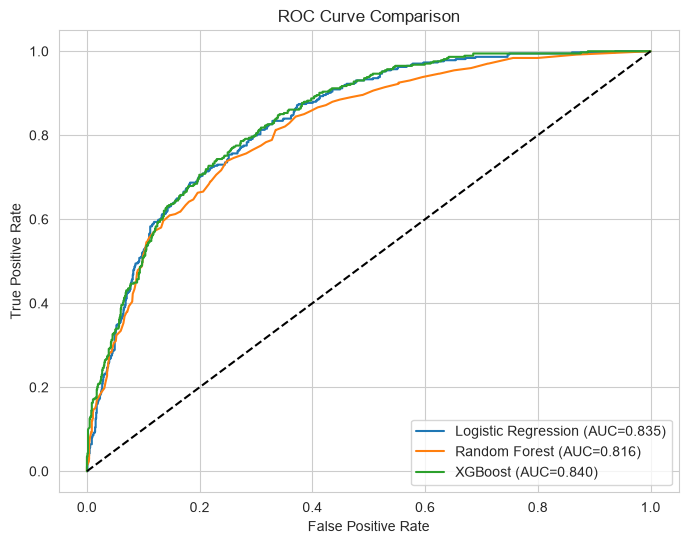

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr_lr,tpr_lr,label=f"Logistic Regression (AUC={auc_lr:.3f})")

plt.plot(fpr_rf,tpr_rf,label=f"Random Forest (AUC={auc_rf:.3f})")

plt.plot(fpr_xgb,tpr_xgb,label=f"XGBoost (AUC={auc_xgb:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()
plt.savefig("../images/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 8: Model Comparison

The three machine learning models are compared using Accuracy and ROC-AUC score.

In [150]:
comparison = pd.DataFrame({

'Model':[
'Logistic Regression',
'Random Forest',
'XGBoost'
],

'Accuracy':[

accuracy_score(y_test,y_pred_lr),

accuracy_score(y_test,y_pred_rf),

accuracy_score(y_test,best_predictions)

],

'ROC-AUC':[

auc_lr,

auc_rf,

auc_xgb

]

})

comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.805970,0.835385
1,Random Forest,0.797441,0.816493
2,XGBoost,0.798152,0.839863


## Step 9: Best Model Selection

Among the three models, the model with the highest ROC-AUC score is selected as the final predictive model because ROC-AUC provides a better evaluation metric for imbalanced classification problems such as customer churn prediction.

In [151]:
best_model = comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

best_model

,Model,Accuracy,ROC-AUC
2,XGBoost,0.798152,0.839863
0,Logistic Regression,0.805970,0.835385
1,Random Forest,0.797441,0.816493


## Step 11: Save the Best Model

The best-performing XGBoost model is saved as a `.pkl` file. This allows the trained model to be reused later for deployment or future predictions without retraining.

In [152]:
import joblib

joblib.dump(best_xgb, "../models/best_xgboost_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [153]:
import os

os.listdir("../models")

['best_xgboost_model.pkl']

# Week 3 Summary

During this phase, an XGBoost classifier was implemented and optimized using GridSearchCV. The tuned XGBoost model was evaluated and compared with Logistic Regression and Random Forest using ROC-AUC and Accuracy. Based on the evaluation results, the best-performing model was selected for interpretation in Week 4.

# Week 4: Interpretability & Final Reporting

## Step 1: Import SHAP

SHAP (SHapley Additive exPlanations) is an Explainable AI (XAI) technique that explains how each feature contributes to the prediction made by the machine learning model.

In [154]:
import shap

## Step 2: Create SHAP Explainer

The SHAP Explainer analyzes the trained XGBoost model and measures the contribution of every feature to each prediction.

In [155]:
explainer = shap.TreeExplainer(best_xgb)

## Step 3: Calculate SHAP Values

SHAP values quantify the contribution of each feature toward predicting customer churn.

In [156]:
shap_values = explainer.shap_values(X_test)

## Step 4: SHAP Summary Plot

The SHAP Summary Plot ranks features based on their overall impact on model predictions and visualizes how feature values influence customer churn.

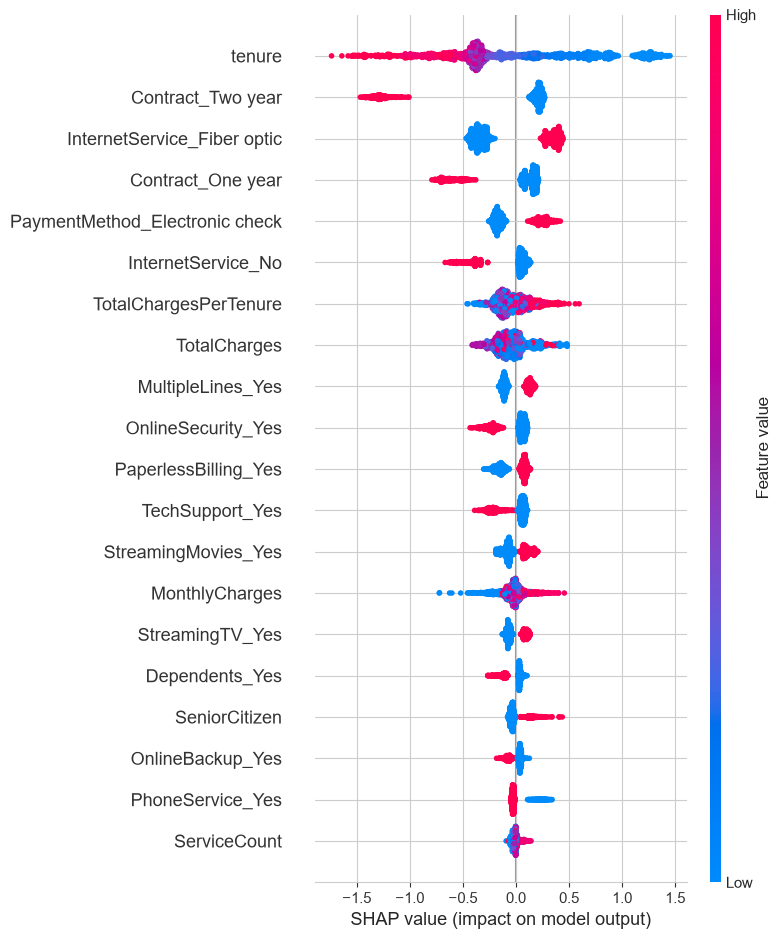

<Figure size 640x480 with 0 Axes>

In [157]:
shap.summary_plot(
    shap_values,
    X_test
)
plt.savefig("../images/roc_curve.png", dpi=300, bbox_inches="tight")

## Step 5: SHAP Feature Importance

The SHAP Bar Plot displays the average contribution of each feature, helping identify the most influential variables in the prediction process.

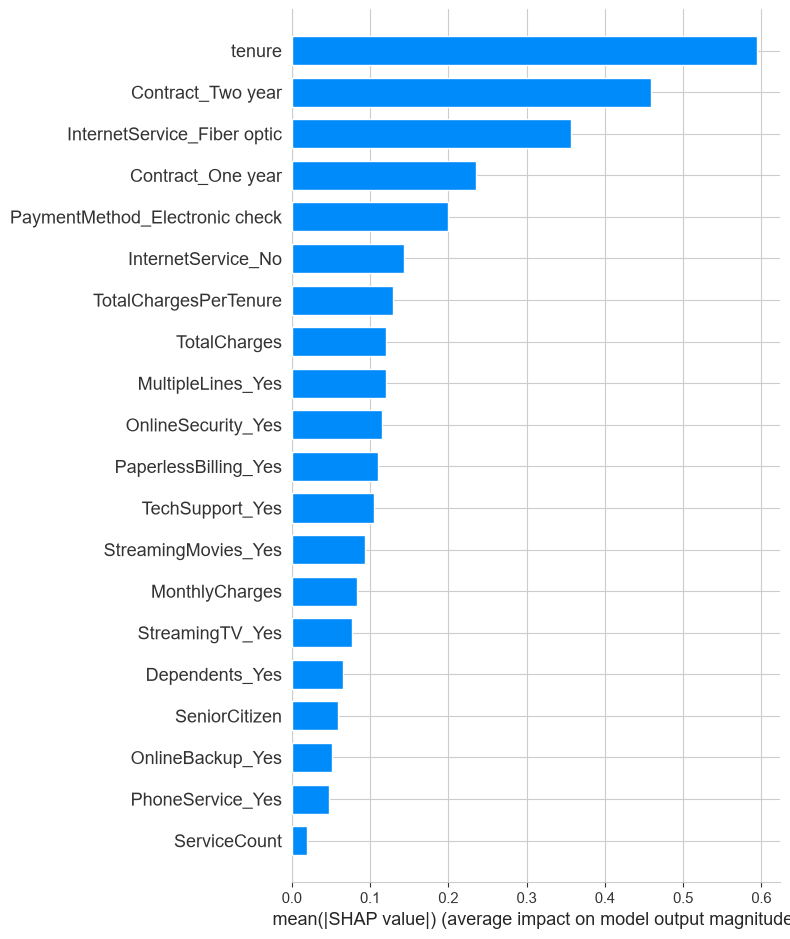

<Figure size 640x480 with 0 Axes>

In [158]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)
plt.savefig("../images/roc_curve.png", dpi=300, bbox_inches="tight")

# Model Interpretation

Based on the SHAP analysis, the following observations were identified:

- Contract type is one of the strongest indicators of customer churn.
- Customers with Month-to-Month contracts have a higher probability of leaving.
- Customers with longer tenure are more likely to remain loyal.
- Higher monthly charges increase the likelihood of customer churn.
- Fiber Optic internet users show a greater tendency to churn.
- Customers using multiple services generally have a lower churn probability.
- Customers with Online Security and Tech Support services are less likely to leave the company.

# Business Recommendations

Based on the model predictions and SHAP analysis, the following recommendations are proposed for ConnectTel:

### Recommendation 1
Offer promotional discounts to customers with Month-to-Month contracts to encourage migration to One-Year or Two-Year contracts.

### Recommendation 2
Review the pricing and service quality of Fiber Optic internet plans, as these customers exhibit higher churn rates.

### Recommendation 3
Launch personalized retention campaigns for customers with high monthly charges.

### Recommendation 4
Provide loyalty rewards to customers during their first 12 months to improve long-term retention.

### Recommendation 5
Promote additional value-added services such as Online Security and Tech Support to increase customer engagement.

### Recommendation 6
Use the developed churn prediction model as an early warning system to identify high-risk customers before they leave.

# Project Conclusion

This project successfully developed an end-to-end machine learning pipeline to predict customer churn for ConnectTel.

The workflow included:

- Data collection and preprocessing
- Exploratory Data Analysis
- Feature Engineering
- Logistic Regression Model
- Random Forest Model
- XGBoost Model
- Hyperparameter Tuning using GridSearchCV
- Model Evaluation using ROC-AUC
- Explainable AI using SHAP

Among all the evaluated models, XGBoost achieved the best overall performance and was selected as the final predictive model.

The SHAP analysis demonstrated that Contract Type, Tenure, Monthly Charges, Internet Service, and Service Count are the most influential factors affecting customer churn.

The developed solution enables ConnectTel to proactively identify customers at high risk of churn and implement targeted retention strategies, thereby reducing customer attrition and improving business revenue.

In [159]:
df.to_csv("../processed_data/Telco_Cleaned.csv", index=False)

In [160]:
import os
os.listdir("../processed_data")

['Telco_Cleaned.csv']

# Future Scope

This project can be further improved by:

- Deploying the model using Flask or Streamlit.
- Building a real-time churn prediction dashboard.
- Integrating customer feedback and support tickets.
- Using Deep Learning models for comparison.
- Automating retraining with new customer data.

In [162]:
import joblib

joblib.dump(best_xgb, "best_xgboost_model.pkl")

['best_xgboost_model.pkl']

In [163]:
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']

In [164]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']